<a href="https://colab.research.google.com/github/TEJASPATIL0710/CSL701-41_Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_No_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Tejas Baburao Patil
Class: B.E.(CSE)
Roll No: 41
Batch No: 03

In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from google.colab import files

df = pd.read_csv("car_data.csv")

print("First 5 records:")
display(df.head())

print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nDataset Information:")
df.info()

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical attributes:")
print(numerical_columns)

print("\nCategorical attributes:")
print(categorical_columns)

y_original = df["selling_price"]

print("Target Variable:")
print(y_original.head())

First 5 records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


Dataset shape: (15411, 14)
Number of rows: 15411
Number of columns: 14

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), 

In [6]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

# Handle numerical missing values

for column in df.select_dtypes(include=np.number).columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())


# Handle categorical missing values

for column in df.select_dtypes(include=["object"]).columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0
Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64


In [7]:
print(df.columns)

df_model = df.drop(columns=["car_name"])

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')


In [8]:
df_encoded = pd.get_dummies(
    df_model,
    columns=["fuel_type", "seller_type", "transmission_type"],
    drop_first=True,
    dtype=int
)

display(df_encoded.head())

print(df_encoded.dtypes)

print("All data types after encoding:")
print(df_encoded.dtypes)

,Unnamed: 0,brand,model,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,0,Maruti,Alto,9,120000,19.70,796,46.30,5,120000,0,0,0,1,1,0,1
1,1,Hyundai,Grand,5,20000,18.90,1197,82.00,5,550000,0,0,0,1,1,0,1
2,2,Hyundai,i20,11,60000,17.00,1197,80.00,5,215000,0,0,0,1,1,0,1
3,3,Maruti,Alto,9,37000,20.92,998,67.10,5,226000,0,0,0,1,1,0,1
4,4,Ford,Ecosport,6,30000,22.77,1498,98.59,5,570000,1,0,0,0,0,0,1


Unnamed: 0                        int64
brand                            object
model                            object
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
selling_price                     int64
fuel_type_Diesel                  int64
fuel_type_Electric                int64
fuel_type_LPG                     int64
fuel_type_Petrol                  int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
transmission_type_Manual          int64
dtype: object
All data types after encoding:
Unnamed: 0                        int64
brand                            object
model                            object
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            i

In [9]:
# The 'KeyError: 'Year'' occurs because there is no column named 'Year' in the DataFrame.
# Instead, the DataFrame contains a 'vehicle_age' column, which already represents the age of the car.
# We will rename 'vehicle_age' to 'Car_Age' to align with the intended feature name.

df_encoded = df_encoded.rename(columns={"vehicle_age": "Car_Age"})

display(
    df_encoded[
        ["Car_Age"]
    ].head(10)
)

print("Minimum Car Age:", df_encoded["Car_Age"].min())
print("Maximum Car Age:", df_encoded["Car_Age"].max())

# The 'CURRENT_YEAR' variable is no longer needed for age calculation as 'vehicle_age' is already the car's age.
# No need to drop 'Year' as it does not exist in the DataFrame.

,Car_Age
0,9
1,5
2,11
3,9
4,6
5,8
6,8
7,3
8,2
9,4


Minimum Car Age: 0
Maximum Car Age: 29


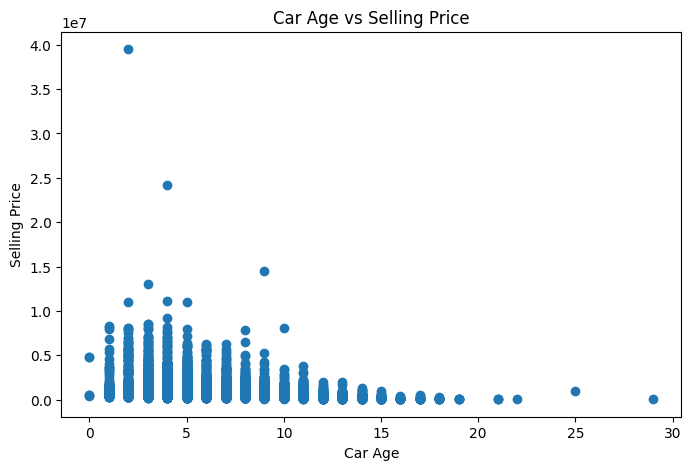

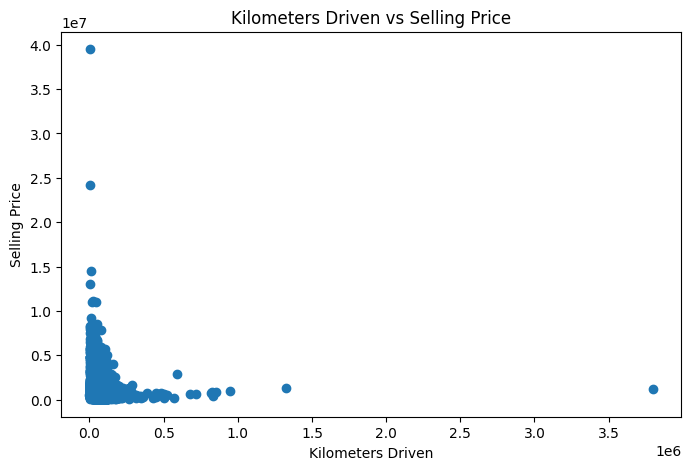

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_encoded["Car_Age"],
    df_encoded["selling_price"]
)

plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.title("Car Age vs Selling Price")

plt.show()

plt.figure(figsize=(8, 5))

plt.scatter(
    df_encoded["km_driven"],
    df_encoded["selling_price"]
)

plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.title("Kilometers Driven vs Selling Price")

plt.show()

In [14]:
X_df = df_encoded.drop(columns=["selling_price", "brand", "model", "Unnamed: 0"])

y = df_encoded["selling_price"].to_numpy()

feature_names = X_df.columns.tolist()

print("Selected Features:")
print(feature_names)

numerical_features = [
    "Car_Age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

print("Numerical features to standardize:")
print(numerical_features)

np.random.seed(42)

n = len(X_df)

indices = np.random.permutation(n)

split_index = int(0.8 * n)

train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_train_df = X_df.iloc[train_indices].copy()
X_test_df = X_df.iloc[test_indices].copy()

y_train = y[train_indices]
y_test = y[test_indices]

print("Training observations:", len(X_train_df))
print("Testing observations:", len(X_test_df))

train_mean = X_train_df[numerical_features].mean()

train_std = X_train_df[numerical_features].std(ddof=0)

train_std = train_std.replace(0, 1)

X_train_df[numerical_features] = (
    X_train_df[numerical_features] - train_mean
) / train_std

print("Standardized Training Data:")
display(X_train_df.head())

Selected Features:
['Car_Age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual']
Numerical features to standardize:
['Car_Age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
Training observations: 12328
Testing observations: 3083
Standardized Training Data:


,Car_Age,km_driven,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
3334,1.976831,0.317732,0.160198,-0.555761,-0.505726,-0.402990,0,0,0,1,0,0,1
10928,-0.673275,0.042356,1.844986,-0.457357,-0.620363,-0.402990,1,0,0,0,1,0,1
2518,0.320515,0.739976,0.258457,-0.457357,-0.275051,2.067455,1,0,0,0,0,0,1
11322,-1.667065,-0.939819,-0.309529,0.025011,0.440606,-0.402990,0,0,0,1,0,0,0
9394,1.645568,0.115790,0.002025,-1.329480,-1.268407,-0.402990,0,0,0,1,0,0,1


In [15]:
X_train = X_train_df.to_numpy(dtype=float)

X_test = X_test_df.to_numpy(dtype=float)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (12328, 13)
y_train shape: (12328,)
X_test shape: (3083, 13)
y_test shape: (3083,)


In [16]:
X_train_bias = np.column_stack(
    (
        np.ones(X_train.shape[0]),
        X_train
    )
)

X_test_bias = np.column_stack(
    (
        np.ones(X_test.shape[0]),
        X_test
    )
)

print("X_train with bias shape:", X_train_bias.shape)

print("X_test with bias shape:", X_test_bias.shape)

X_train with bias shape: (12328, 14)
X_test with bias shape: (3083, 14)


In [17]:
def ordinary_least_squares(X, y):

    # Calculate X transpose
    X_transpose = X.T

    # Calculate X^T X
    XTX = X_transpose @ X

    # Calculate X^T y
    XTy = X_transpose @ y

    # Calculate inverse of X^T X
    XTX_inverse = np.linalg.inv(XTX)

    # Calculate regression coefficients
    beta = XTX_inverse @ XTy

    return beta

In [18]:
XTX = X_train_bias.T @ X_train_bias

determinant = np.linalg.det(XTX)

print("Determinant of X^T X:")
print(determinant)

if np.isclose(determinant, 0):
    print("X^T X is singular or nearly singular.")
    print("Feature redundancy or multicollinearity may exist.")
else:
    print("X^T X is non-singular.")
    print("OLS normal equation can be applied.")

Determinant of X^T X:
4.0286876476715137e+43
X^T X is non-singular.
OLS normal equation can be applied.


In [19]:
beta = ordinary_least_squares(
    X_train_bias,
    y_train
)

print("Regression Coefficients:")
print(beta)

coefficient_names = ["Intercept"] + feature_names

print("\nRegression Coefficients:\n")

for name, coefficient in zip(
    coefficient_names,
    beta
):
    print(f"{name}: {coefficient:.6f}")

Regression Coefficients:
[ 994217.80724365 -195163.09053546  -34965.02601204   62397.2943623
   48021.8182965   644333.49945542    6812.17431665 -124692.4295625
  -96756.41053173  358735.63796481 -119859.21560939   -6783.55536347
  -78002.67281776 -121450.23037615]

Regression Coefficients:

Intercept: 994217.807244
Car_Age: -195163.090535
km_driven: -34965.026012
mileage: 62397.294362
engine: 48021.818296
max_power: 644333.499455
seats: 6812.174317
fuel_type_Diesel: -124692.429563
fuel_type_Electric: -96756.410532
fuel_type_LPG: 358735.637965
fuel_type_Petrol: -119859.215609
seller_type_Individual: -6783.555363
seller_type_Trustmark Dealer: -78002.672818
transmission_type_Manual: -121450.230376


In [20]:
for name, coefficient in zip(
    coefficient_names,
    beta
):

    if coefficient > 0:
        direction = "Positive"
    elif coefficient < 0:
        direction = "Negative"
    else:
        direction = "Zero"

    print(
        f"{name}: "
        f"{coefficient:.6f} "
        f"({direction})"
    )

feature_coefficients = beta[1:]

absolute_coefficients = np.abs(
    feature_coefficients
)

sorted_indices = np.argsort(
    absolute_coefficients
)[::-1]

print("Features ranked by absolute coefficient magnitude:\n")

for index in sorted_indices:
    print(
        feature_names[index],
        ":",
        feature_coefficients[index]
    )

Intercept: 994217.807244 (Positive)
Car_Age: -195163.090535 (Negative)
km_driven: -34965.026012 (Negative)
mileage: 62397.294362 (Positive)
engine: 48021.818296 (Positive)
max_power: 644333.499455 (Positive)
seats: 6812.174317 (Positive)
fuel_type_Diesel: -124692.429563 (Negative)
fuel_type_Electric: -96756.410532 (Negative)
fuel_type_LPG: 358735.637965 (Positive)
fuel_type_Petrol: -119859.215609 (Negative)
seller_type_Individual: -6783.555363 (Negative)
seller_type_Trustmark Dealer: -78002.672818 (Negative)
transmission_type_Manual: -121450.230376 (Negative)
Features ranked by absolute coefficient magnitude:

max_power : 644333.4994554151
fuel_type_LPG : 358735.6379648149
Car_Age : -195163.09053546144
fuel_type_Diesel : -124692.42956250344
transmission_type_Manual : -121450.2303761458
fuel_type_Petrol : -119859.21560939436
fuel_type_Electric : -96756.41053173272
seller_type_Trustmark Dealer : -78002.67281775875
mileage : 62397.2943623006
engine : 48021.81829649568
km_driven : -34965.0

In [21]:
y_pred = X_test_bias @ beta

comparison = pd.DataFrame({
    "Actual_Selling_Price": y_test,
    "Predicted_Selling_Price": y_pred
})

display(comparison.head(10))

,Actual_Selling_Price,Predicted_Selling_Price
0,4450000,-6.604960e+08
1,1290000,-2.537344e+09
2,485000,-2.076714e+09
3,400000,-7.655888e+08
4,800000,-6.530415e+08
5,150000,-3.428972e+09
6,650000,-1.436725e+09
7,325000,-3.739163e+09
8,300000,-2.672587e+09
9,925000,-2.226668e+09


In [22]:
residuals = y_test - y_pred

RSS = np.sum(
    residuals ** 2
)

print("Residual Sum of Squares (RSS):", RSS)

Residual Sum of Squares (RSS): 1.5387163932127484e+22


In [23]:
y_test_mean = np.mean(y_test)

TSS = np.sum(
    (y_test - y_test_mean) ** 2
)

R_squared = 1 - (RSS / TSS)

print("R² Score:", R_squared)

R² Score: -6391649.530945644


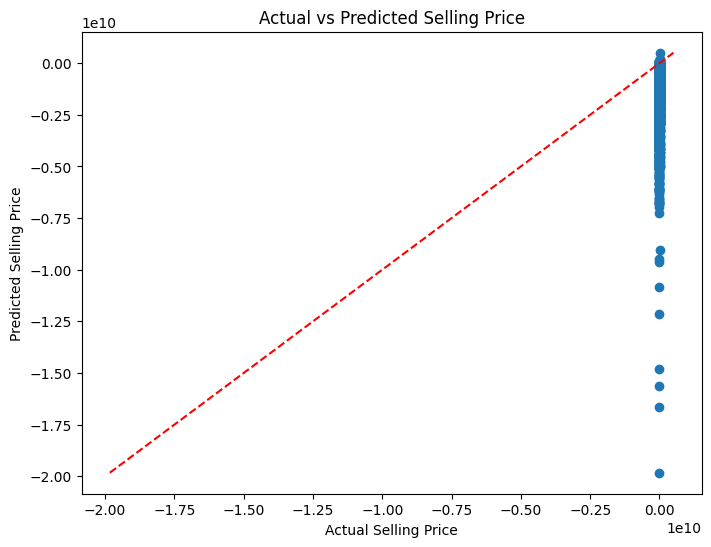

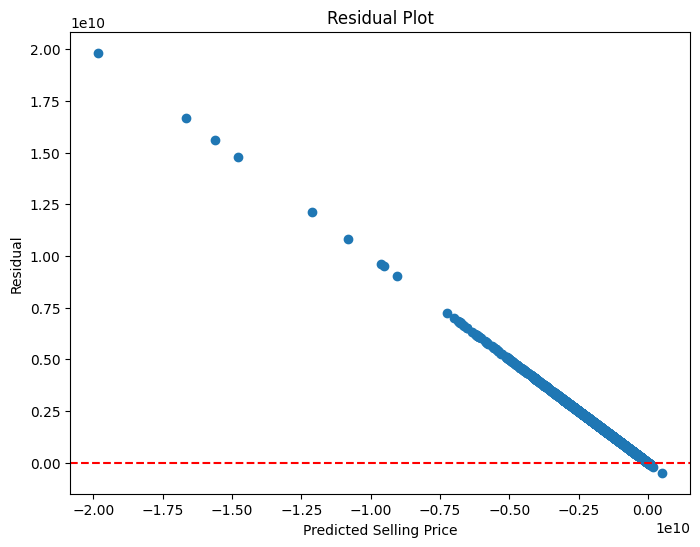

Observations with largest prediction errors:


,Actual,Predicted,Residual,Absolute_Error
2921,200000,-1.982772e+10,1.982792e+10,1.982792e+10
1840,650000,-1.666494e+10,1.666559e+10,1.666559e+10
2189,690000,-1.560843e+10,1.560912e+10,1.560912e+10
3050,195000,-1.479632e+10,1.479652e+10,1.479652e+10
2064,173000,-1.213295e+10,1.213312e+10,1.213312e+10
912,500000,-1.082963e+10,1.083013e+10,1.083013e+10
261,500000,-9.628218e+09,9.628718e+09,9.628718e+09
2780,750000,-9.500688e+09,9.501438e+09,9.501438e+09
2269,1300000,-9.048836e+09,9.050136e+09,9.050136e+09
833,350000,-7.234174e+09,7.234524e+09,7.234524e+09


In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred
)

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "r--"
)

plt.xlabel("Actual Selling Price")

plt.ylabel("Predicted Selling Price")

plt.title(
    "Actual vs Predicted Selling Price"
)

plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel(
    "Predicted Selling Price"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residual Plot"
)

plt.show()

error_analysis = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": residuals,
    "Absolute_Error": np.abs(residuals)
})

large_errors = error_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
)

print("Observations with largest prediction errors:")

display(
    large_errors.head(10)
)

The Multiple Linear Regression model was successfully implemented from scratch using NumPy matrix operations and the Ordinary Least Squares normal equation. The model was trained to predict the selling price of used cars using multiple numerical and categorical features from the CarDekho Used Car Dataset.

Data preprocessing included checking for missing values, removing the high-cardinality `Car_Name` attribute, converting categorical variables into dummy variables, and creating the new `Car_Age` feature. The original `Year` feature was removed because it was directly related to `Car_Age`, and retaining both variables could introduce perfect multicollinearity and make the matrix (X^T X) singular.

The dataset was divided into 80% training data and 20% testing data using a fixed random seed. Numerical predictors were standardized using the mean and standard deviation calculated only from the training dataset. The regression coefficients were calculated using the OLS normal equation:

[
\hat{\beta} = (X^T X)^{-1}X^Ty
]

The trained model produced a Residual Sum of Squares (RSS) of **[YOUR RSS VALUE]** and an (R^2) value of **[YOUR R² VALUE]** on the test dataset. The (R^2) value indicates the proportion of variation in used-car selling prices explained by the selected predictor variables.

Features such as `Present_Price` and `Car_Age` are expected to have a significant influence on the predicted selling price. Generally, a higher present price tends to increase the predicted selling price, whereas an increase in car age tends to decrease it.

The experiment demonstrated that Multiple Linear Regression using the OLS normal equation can effectively model a substantial part of the relationship between vehicle characteristics and selling price. However, the model has limitations because real-world car prices may depend on nonlinear relationships and additional factors such as brand reputation, vehicle condition, demand, location, accident history, and exact model specifications. Therefore, although the linear model provides an interpretable and computationally simple approach, more advanced regression models may provide improved prediction accuracy for complex real-world datasets.
